# Variability

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = '/lhome/nicholas/software/workdir/mocka'
idir = f'{path}/input'
vdir = '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim'

## Synthetic SEDs for VarSim

In [11]:
# Valid paramter space for PHOENIX spectra
valid_t_phoenix = np.array([*list(range(2300, 7000, 100)), 
                            *list((range(7000, 12200, 200)))])
valid_g_phoenix = np.array([*list(np.arange(0, 6, 0.5))])

# Valid parameter space for ATLAS9 spectra
valid_t_atlas9 = np.array([*list(range(3000, 1300, 250)), 
                           *list((range(13000, 50000, 1000)))])

<IPython.core.display.Javascript object>


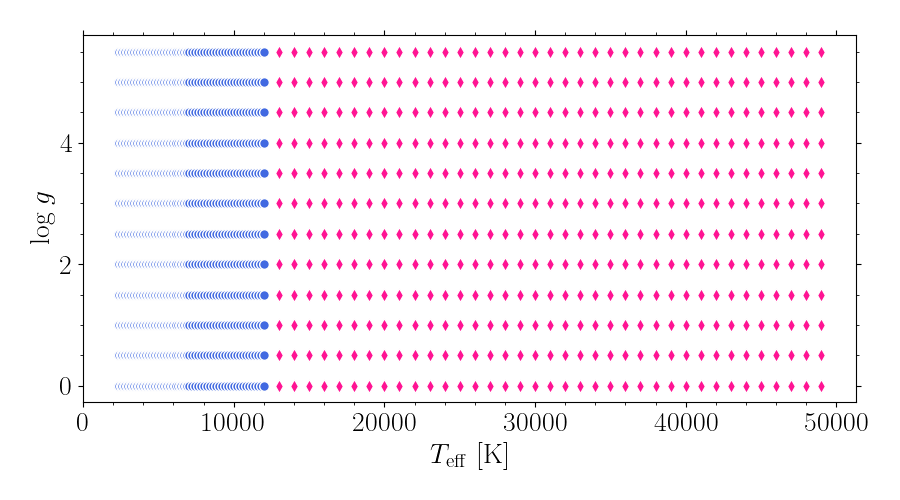

In [12]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for i in range(len(valid_g_phoenix)):
    ax.plot(valid_t_phoenix, np.ones_like(valid_t_phoenix)*valid_g_phoenix[i], 
            'o', c='royalblue', mec='w', ms=7)
    ax.plot(valid_t_atlas9,  np.ones_like(valid_t_atlas9)*valid_g_phoenix[i], 
            'd', c='deeppink', mec='w', ms=7)
    
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel('log $g$')
plt.tight_layout()

## $\gamma$ Doradus- stars (Gang+2020)

In [5]:
# 
filenames = glob.glob(f'{vdir}/varsource_gdor_gang2020/*.dat')
N = len(filenames)
dv = pd.DataFrame()
N_mod = np.zeros(N)
A_max = np.zeros(N)
P_max = np.zeros(N)
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    dv_i = pd.read_csv(f, sep=' ', comment='#', names=['per', 'amp', 'phi', 'snr'])
    dv = pd.concat([dv, dv_i])
    # Store
    N_mod[i] = dv_i.shape[0]
    dv_max = dv_i[dv_i.amp == dv_i.amp.max()]
    A_max[i] = dv_max.amp
    P_max[i] = dv_max.per
    
# Convert units
dv.per /= 24                           # [d]
dv.amp *= -2.5*np.log10(dv.amp) * 1e3  # [mmag]
P_max  /= 24
A_max  *= -2.5*np.log10(A_max) * 1e3

dv = dv.reset_index(drop=True)
dv.to_feather(f'{vdir}/varsim_gang2020gdor.ftr')
# df = pd.DataFrame()
# df['N_mod'] = N_mod
# df['P_max'] = P_max
# df['A_max'] = A_max
# df.to_feather(f'{vdir}/varsim_gang2020gdor_max.ftr')

100%|█████████████████████████████████████████████████▉| 607/608 [00:01<00:00, 344.24it/s]                                                                    


In [6]:
# Generate KDEs
N_kde = scipy.stats.gaussian_kde(N_mod)
P_kde = scipy.stats.gaussian_kde(dv.per)
A_kde = scipy.stats.gaussian_kde(dv.amp)
P_max_kde = scipy.stats.gaussian_kde(P_max)
A_max_kde = scipy.stats.gaussian_kde(A_max)

<IPython.core.display.Javascript object>


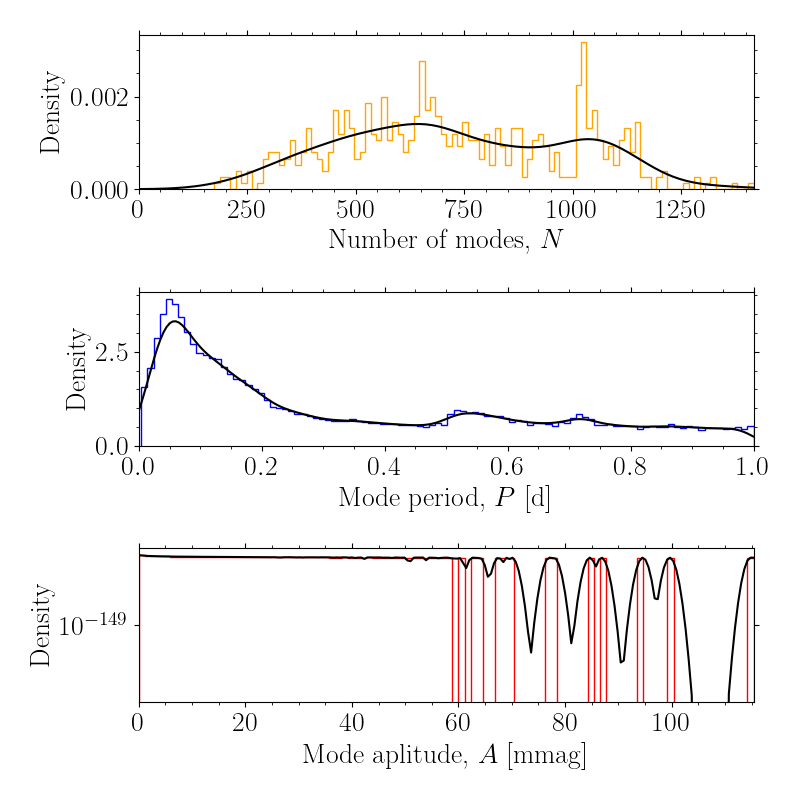

In [7]:
# HISTOGRAMS OF GENRAL MODE PROPERTIES
fig, ax = plt.subplots(3,1, figsize=(8,8))
bins = 100
grid = 200

h = ax[0].hist(N_mod, bins=bins, histtype='step', density=True, ec='orange')
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dv.per, bins=bins, histtype='step', density=True, ec='blue')
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax[1].plot(P_range, P_kde_hist, 'k-')
ax[1].set_xlim(0, P_range.max())
ax[1].set_xlabel(r'Mode period, $P$ [d]')

h = ax[2].hist(dv.amp, bins=bins, histtype='step', density=True, ec='red')
A_range = np.linspace(0, h[1].max(), grid)
A_kde_hist = A_kde(A_range) #+ dv.amp.min() 
ax[2].plot(A_range, A_kde_hist, 'k-')
ax[2].set_xlim(0, A_range.max())
ax[2].set_yscale('log')
ax[2].set_xlabel(r'Mode aplitude, $A$ [mmag]')

for i in range(3): ax[i].set_ylabel('Density')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


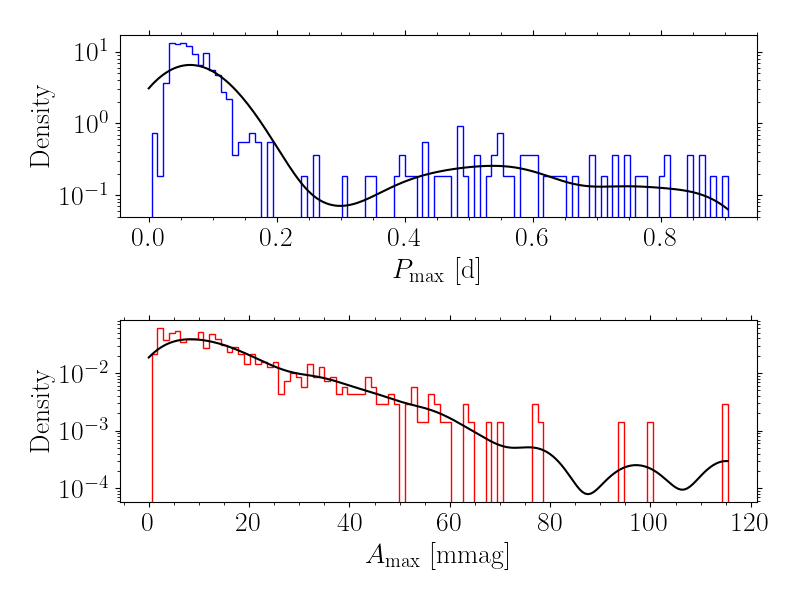

In [8]:
# HISTOGRAMS OF MODE WITH MAXIMUM AMPLITUDE
fig, ax = plt.subplots(2,1, figsize=(8,6))

h = ax[0].hist(P_max, bins=bins, histtype='step', density=True, ec='blue')
P_max_range = np.linspace(0, h[1].max(), grid)
P_max_kde_hist = P_max_kde(P_max_range)
ax[0].plot(P_max_range, P_max_kde_hist, 'k-')
ax[0].set_xlabel(r'$P_{\rm max}$ [d]')
ax[0].set_yscale('log')

h = ax[1].hist(A_max, bins=bins, histtype='step', density=True, ec='red')
A_max_range = np.linspace(0, h[1].max(), grid)
A_max_kde_hist = A_max_kde(A_max_range) # + A_max.min() 
ax[1].plot(A_max_range, A_max_kde_hist, 'k-')
ax[1].set_xlabel(r'$A_{\rm max}$ [mmag]')
ax[1].set_yscale('log')

for i in range(2): ax[i].set_ylabel('Density')
plt.tight_layout()
plt.show()

### *Modes from pattern*

In [31]:
filenames = glob.glob(f'{vdir}/public_data/*')
N = len(filenames)

dm = pd.DataFrame()
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)

# Loop over each star
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    starfiles = glob.glob(f'{f}/*')
        
    # For each star check each file 
    for s in starfiles:

        # Load only dipole sectoral modes (l,m)=(1,1)
        if s[-18:-15] == 'k=0' and s[-14:-11] == 'm=1': 
            dv_i = pd.read_csv(s, sep=' ', skiprows=1, names=['per', 'per_err'])
            
            # Remove mising modes and store periods
            dm_i = dv_i[~(dv_i.per == 9999.0)]
            dm = pd.concat([dm, dm_i])   
            
            # Number of modes (including missing ones)
            N_mod[i] = dm_i.shape[0]
            
            # First period in pattern
            P0[i] = dm_i.per.iloc[0]
            
            # Calculate period spacings [days]
            n = int(dv_i.shape[0])-1
            dx = pd.DataFrame()
            dx['delta_P'] = dv_i.per.diff().dropna()
            dx['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
            # Remove undefined modes
            dx = dx[~(dx.delta_P.abs() > 10) & ~(dx.delta_P.abs() == 0.0)]
            
            # First period spacing
            dP0[i] = dx.delta_P.iloc[0]
            
            # Fit and find slope
            coeff = np.polyfit(dx.P_mean, dx.delta_P, 1)
            slope[i] = coeff[0]
#             plt.figure()
#             plt.plot(dx.P_mean, dx.delta_P, 'b*')
#             plt.show()
#     if i == 0:
#         break

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm = dm.to_feather(f'{vdir}/varsim_gang2020gdor_all.ftr')

100%|█████████████████████████████████████████████████▉| 608/609 [00:01<00:00, 348.60it/s]                                                                    


In [32]:
# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)

<IPython.core.display.Javascript object>


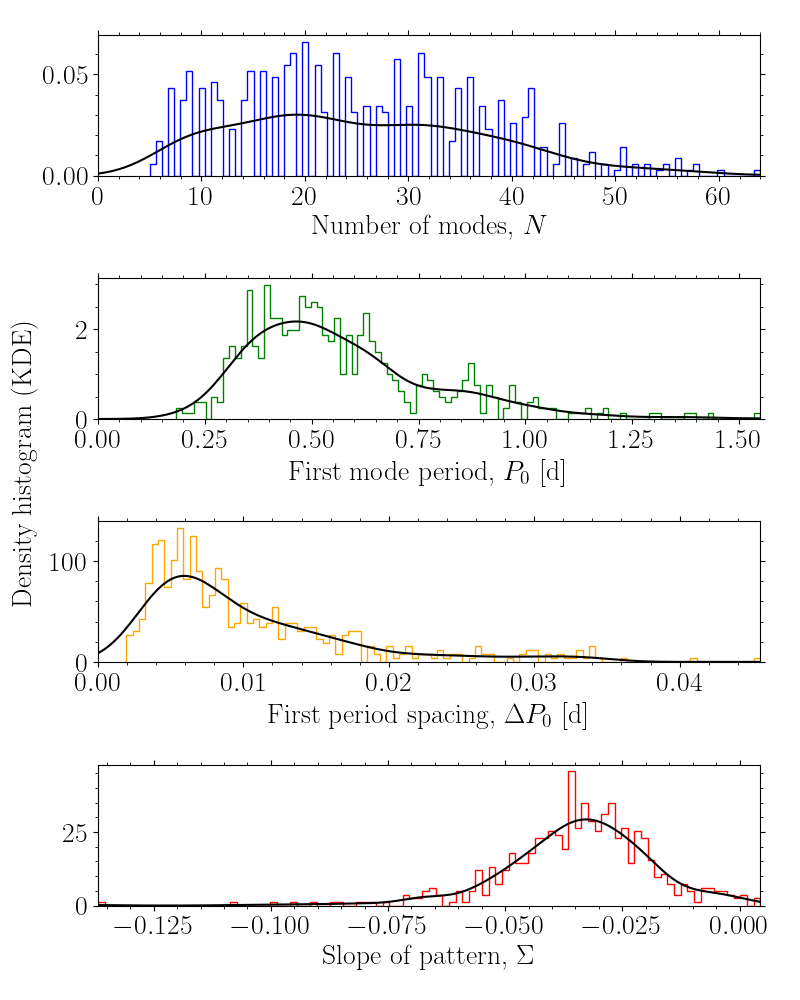

In [33]:
# HISTOGRAMS OF GENRAL MODE PROPERTIES
fig, ax = plt.subplots(4,1, figsize=(8,10))
bins = 100
grid = 200

h = ax[0].hist(dm.N, bins=bins, histtype='step', density=True, ec='blue')
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dm.P0, bins=bins, histtype='step', density=True, ec='green')
P0_range = np.linspace(0, h[1].max(), grid)
P0_kde_hist = P0_kde(P0_range)
ax[1].plot(P0_range, P0_kde_hist, 'k-')
ax[1].set_xlim(0, P0_range.max())
ax[1].set_xlabel(r'First mode period, $P_0$ [d]')

h = ax[2].hist(dm.dP0, bins=bins, histtype='step', density=True, ec='orange')
dP0_range = np.linspace(0, h[1].max(), grid)
dP0_kde_hist = dP0_kde(dP0_range)
ax[2].plot(dP0_range, dP0_kde_hist, 'k-')
ax[2].set_xlim(0, dP0_range.max())
ax[2].set_xlabel(r'First period spacing, $\Delta P_0$ [d]')

h = ax[3].hist(dm.slope, bins=bins, histtype='step', density=True, ec='red')
slope_range = np.linspace(h[1].min(), h[1].max(), grid)
slope_kde_hist = slope_kde(slope_range)
ax[3].plot(slope_range, slope_kde_hist, 'k-')
ax[3].set_xlim(slope_range.min(), slope_range.max())
ax[3].set_xlabel(r'Slope of pattern, $\Sigma$')

fig.text(0.03, 0.4, 'Density histogram (KDE)', ha='center', rotation='vertical')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


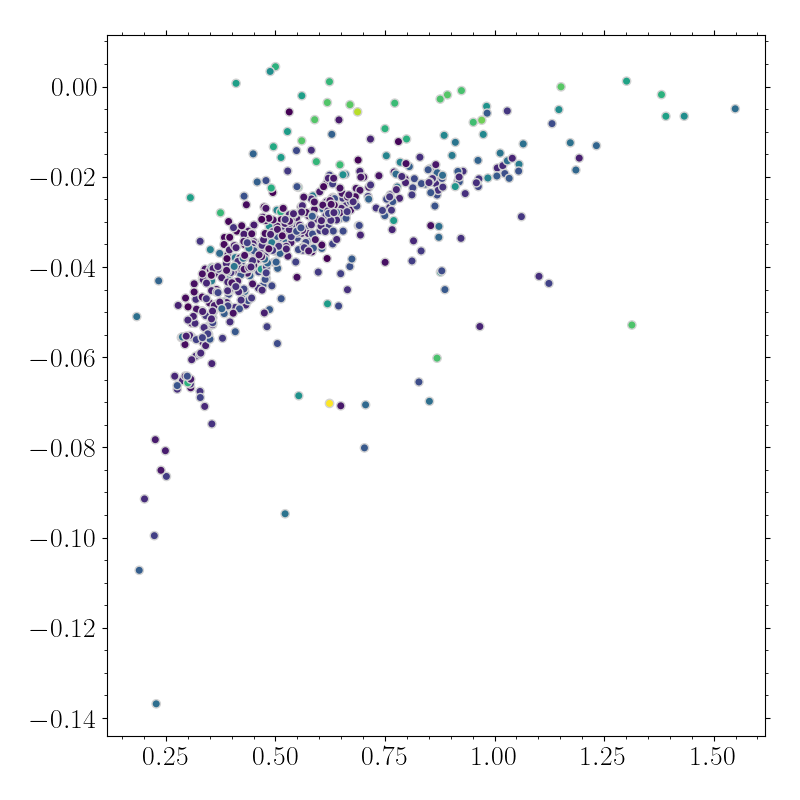

In [43]:
# Plot period spacing pattern
fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(dm.P0, dm.slope, c=dm.dP0, edgecolors='lightgray')
plt.tight_layout()
plt.show()

In [29]:
#----- Modes in pattern

# Select number modes
# N_mod = pd.DataFrame(x0).sample(1, weights= N_modes_kde).iloc[0]
N = np.random.randint(20, 40) 

# Select maximum period from KDE
P0_ran = np.linspace(dm.P0.min(), dm.P0.max(), 1000)
P0 = pd.Series(P0_ran).sample(1, weights=P0_kde(P0_ran)).to_numpy()[0]

# First period spacing in pattern from KDE
dP0_ran = np.linspace(dm.dP0.min(), dm.dP0.max(), 1000)
dP0 = pd.Series(dP0_ran).sample(1, weights=dP0_kde(dP0_ran)).to_numpy()[0]

# Select slope from distribution (cf. Fig. 10 of L20)
slope_ran = np.linspace(dm.slope.min(), dm.slope.max(), 1000)
slope = pd.Series(slope_ran).sample(1, weights=slope_kde(slope_ran)).to_numpy()[0]

# Create period-spacing pattern
P_i = np.array([dP0 * ((1 + slope)**i - 1)/slope + P0 for i in range(N)])
# P_i -= (P_i[n_dex] - P_i[0])

# Draw amplitude below maximum
A_i_ran = np.linspace(A_max.min(), A_max.max(), 1000)
A_i = pd.Series(A_i_ran).sample(N, weights=A_kde(A_i_ran)).to_numpy()

# Max peak amplitude
n_max = np.argmax(A_i)
A_max0 = A_i[n_max]

# Swap max peak location with offset
n_off = np.random.randint(-5, 5)
n_dex = int(N/2 + n_off)
print(n_off, n_dex, N)
A_i[n_max] = A_i[n_dex]
A_i[n_dex] = A_max0

#----- Noise peaks

# Draw random periods not part of the pattern
M = np.random.randint(100, 300)
P_puls_i = np.random.uniform(0, 2, size=M)
A_puls_i = np.random.uniform(0, A_max0/8, size=M)

-5 13 37


<IPython.core.display.Javascript object>


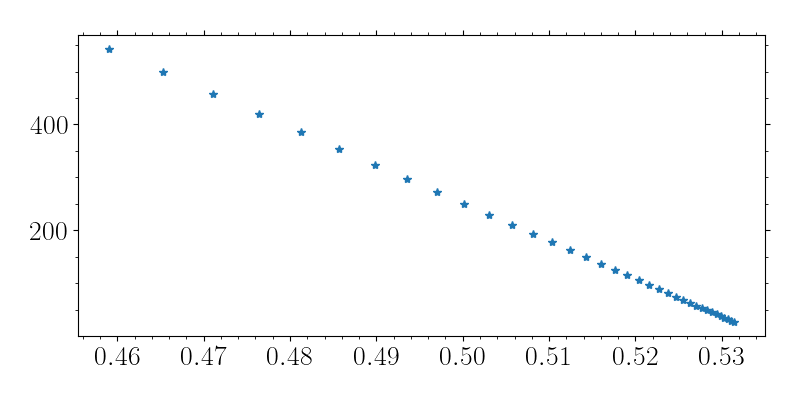

<IPython.core.display.Javascript object>


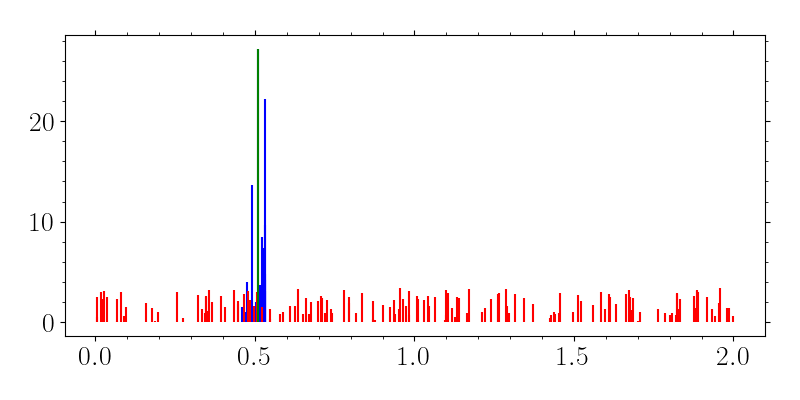

In [30]:
#----- Plots

# Plot period spacing pattern
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(P_i[:-1], np.diff(P_i)*86400, '*')
plt.tight_layout()
plt.show()

# Plot periodogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
for i in range(N):
    ax.vlines(x=P_i[i], ymin=0, ymax=A_i[i], colors='b', label='Pattern')
for i in range(M):
    ax.vlines(x=P_puls_i[i], ymin=0, ymax=A_puls_i[i], colors='r', label='Extra pulsations')
ax.vlines(x=P_i[n_dex], ymin=0, ymax=A_i[n_dex], colors='g', label='Max puls')
plt.tight_layout()
plt.show()

## $\delta$ Scuti stars (Bowman+2018)

In [26]:
filenames = glob.glob(f'{vdir}/varsource_dsct_bowman2018/*.txt')

dv = pd.DataFrame()
for f in tqdm(filenames, bar_format=ut.tqdmBar()):
    dv_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    dv = pd.concat([dv, dv_i])

100%|██████████████████████████████████████████████████| 186/186 [00:00<00:00, 1087.68it/s]                                                                   


In [27]:
P_kde = scipy.stats.gaussian_kde(dv.freq)
A_kde = scipy.stats.gaussian_kde(dv.ampl)

<IPython.core.display.Javascript object>


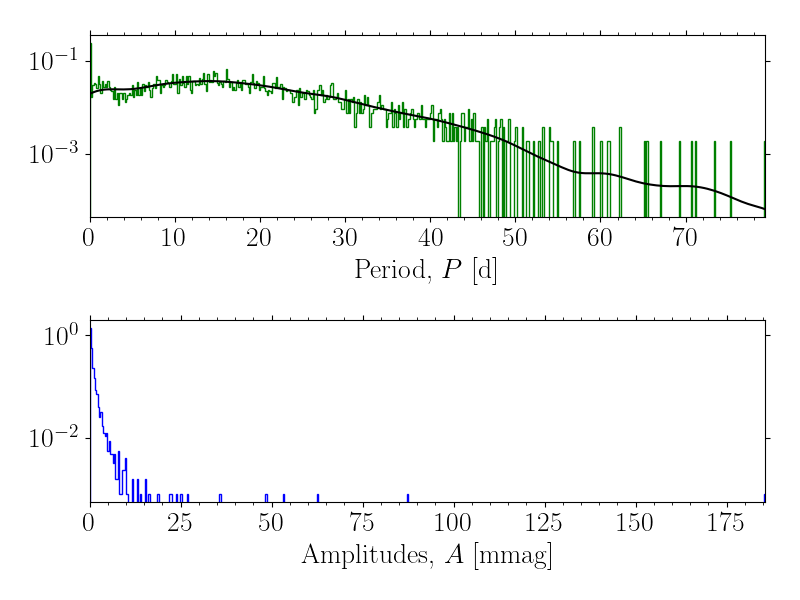

In [28]:
N = 100
grid = 200
bins = 500

fig, ax = plt.subplots(2,1, figsize=(8,6))

h = ax[0].hist(dv.freq, bins=bins, histtype='step', density=True, ec='green')
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax[0].plot(P_range, P_kde_hist, 'k-')
ax[0].set_xlim(0, P_range.max())
ax[0].set_xlabel(r'Period, $P$ [d]')
ax[0].set_yscale('log')

h = ax[1].hist(dv.ampl, bins=bins, histtype='step', density=True, ec='blue')
A_range = np.linspace(0, h[1].max(), grid)
A_kde_hist = A_kde(A_range)
# ax[1].plot(A_range, A_kde_hist, 'k-')
ax[1].set_xlim(0, A_range.max())
ax[1].set_xlabel(r'Amplitudes, $A$ [mmag]')
ax[1].set_yscale('log')

# # Inspect magnitude counts
# fig, ax = plt.subplots(1,1, figsize=(8,4))
# ax.hist(dv.ampl, bins=N, histtype='step', ec='r')
# ax.set_xlabel(r'Amplitude, $A$ [mmag]')
# ax.set_ylabel('Count')
# ax.set_yscale('log')
plt.tight_layout()
# plt.show()